In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import cmapPy.pandasGEXpress.parse as parse
from matplotlib_venn import venn2

indir = 'input'
outdir = 'output'

### Map the perturbations to the ENSG indentifiers

In [3]:
#dataframe for converting between ENSG and Gene symbols
names = pd.read_csv(f'{indir}/mart_export.txt.gz',compression='gzip').dropna(subset='Gene name')
names = names.drop_duplicates('Gene stable ID')
names = names[['Gene stable ID','Gene name']]

extra_names = {'PRPF4B-':['ENSG00000112739'],
               'SLC9A3R2-':['ENSG00000065054'],
               'FAM83H-AS1-':['ENSG00000203499'],
               'ENSG00000170846-':['ENSG00000170846'],
               'AARS-':['ENSG00000090861'],
               'ATP5C1-':['ENSG00000165629'],
               'TROVE2-':['ENSG00000116747'],
               'WHSC1-':['ENSG00000109685'],
               'AARS-':['ENSG00000090861'],
               'GNB2L1-':['ENSG00000204628'],
               'AP1-':['ENSG00000177606'],
               'ERG-wt+':['ENSG00000157554'],
               'NR2F2; rs10846744(G>C)-':['ENSG00000185551'],
               'rs10846744(G>C); NR2F2-':['ENSG00000185551'],
               'LINC00673-':['ENSG00000227036'],
               'PPP1CC-PPP1R8(p.Ser68Ala;Arg69Ala;Val70Ala;His71Ala)_fusion_transgene+':['ENSG00000186298','ENSG00000117751'],
               'PPP1CC-PPP1R8_fusion_transgene+':['ENSG00000186298','ENSG00000117751'],
               'TCF3-PBX1-':['ENSG00000071564','ENSG00000185630'],
               'TP53; IDH1(p.Arg132His)-':['ENSG00000141510','ENSG00000138413'],
               'AFF4; AFF1-':['ENSG00000172493','ENSG00000072364'],
               'CD86; MCL1+':['ENSG00000114013','ENSG00000143384'],
               'GLIS3; INS-':['ENSG00000107249','ENSG00000254647'],
               'POU5F1; KLF4; MYC; SOX2+':['ENSG00000237582','ENSG00000136826','ENSG00000136997','ENSG00000181449'],
               'KLF6-super-enhancer-':['ENSG00000067082'],
               'SRRM2/3/4(amphioxus; alternative_N_terminus; alternative_C_terminus)+':['ENSG00000167978','ENSG00000177679','ENSG00000139767'],
               'SRRM2/3/4(amphioxus; alternative_N_terminus; alternative_C_terminus)-':['ENSG00000167978','ENSG00000177679','ENSG00000139767'],
               'SRRM2/3/4(amphioxus; reference_N_terminus; alternative_C_terminus)+':['ENSG00000167978','ENSG00000177679','ENSG00000139767'],
               'SRRM2/3/4(fruitfly; alternative_C_terminus)+':['ENSG00000167978','ENSG00000177679','ENSG00000139767'],
               'Pan3(L)-':['ENSG00000152520'],
               'Pan3(S)-':['ENSG00000152520'],
              }

### Load the perturbation dataset and label each row by the perturbed gene

In [4]:
Delta_gcts = parse.parse(f'{indir}/gene_perturbations.gctx')
delta_row_meta = Delta_gcts.row_metadata_df
rid2pert = {}
for rx,row in delta_row_meta.iterrows():
    ext = '-' if row.loc['sense'].startswith('kd') else ('+' if row.loc['sense'].startswith('oe') else '*')
    if row.init_genotype=='NONE':
        pert = row.loc['fin_genotype']
        rid2pert[rx]=f'{pert}{ext}'
    else:
        if rx not in ['43595','43803']:
            pert_l = list(set(row.loc['fin_genotype'].split('; '))-set(row.loc['init_genotype'].split('; ')))
            pert = '; '.join(pert_l) if len(pert_l)>0 else pert_l[0]
            rid2pert[rx]=f'{pert}{ext}'
        elif rx in ['43803']:
            pert = row.loc['init_genotype']
            rid2pert[rx]=f'{pert}{ext}'
        else:
            pert = row.loc['fin_genotype']
            rid2pert[rx]=f'{pert}{ext}'
rid2pert_ser = pd.Series(rid2pert)

In [5]:


## confirm all perturbations are mapped to one (or more) ENSG identifiers
mssng = []
for pert in rid2pert_ser.values:
    ## the last character of pert indicates the sense of the perturbation
    if pert[:-1] not in names['Gene name'].values:
        if pert.split('(')[0] not in names['Gene name'].values:
            if pert not in extra_names.keys():
                mssng.append(pert)
print(sorted(list(set(mssng)))) ## should be empty

#construct column mapping to ENSG to facilitate comparisons with DE and TWAS.
col2ENSG_d = {}
ind2ENSG_d = {}
pert2ENSG_d = {}
for ii,(col,pert) in enumerate(rid2pert_ser.items()):
    ## the last character of pert indicates the sense of the perturbation
    if pert[:-1] not in names['Gene name'].values:
        if pert.split('(')[0] not in names['Gene name'].values:
            ensg_l = extra_names[pert]
        else:
            ensg_l = names[names['Gene name']==pert.split('(')[0]]['Gene stable ID'].unique().tolist()
    else:
        ensg_l = names[names['Gene name']==pert[:-1]]['Gene stable ID'].unique().tolist()
    col2ENSG_d[col]=ensg_l
    ind2ENSG_d[ii]=ensg_l
    pert2ENSG_d[pert]=ensg_l

[]


# IBD

## DE vs. TWAS agreement

### Import Expression data

In [6]:
Xr_ibd = np.load(f'{indir}/Xr_ibd.npy') #ibd data
keys_ibd = np.load(f'{indir}/gene_keys_ib_rna_seq.npy') #ensg gene names

print(Xr_ibd.shape, ' data shape')
print(keys_ibd.shape, ' keys shape')

indices = pd.MultiIndex.from_tuples([('control',ii) for ii in range(Xr_ibd.shape[1])]+
                                    [('case',ii) for ii in range(Xr_ibd.shape[1])])
ibd_df = pd.DataFrame(np.vstack([Xr_ibd[0,:,:],Xr_ibd[1,:,:]]),index=indices,columns=keys_ibd)

(2, 2000, 21973)  data shape
(21973,)  keys shape


### Make histogram of a single gene for both case and control

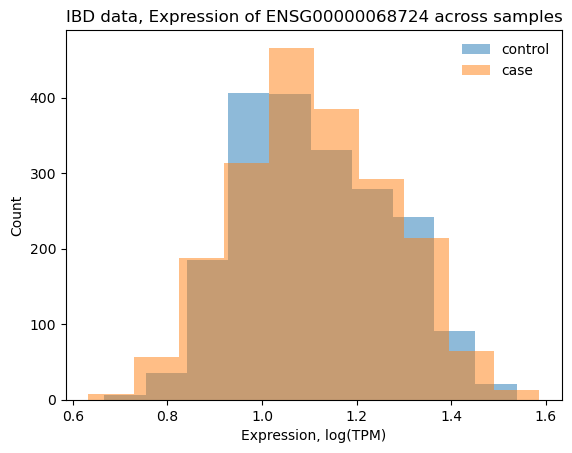

In [10]:
n=1000
fig,ax = plt.subplots(1,1)
for state in ['control','case']:
    ax.hist(ibd_df.xs(state).iloc[:,n],alpha=.5,label=state)
ax.set_title('IBD data, Expression of {} across samples'.format(ibd_df.columns[n]) )
ax.set_ylabel('Count')
ax.set_xlabel('Expression, log(TPM)')
ax.legend(frameon=False)

### Make histogram of a single profile for both case and control

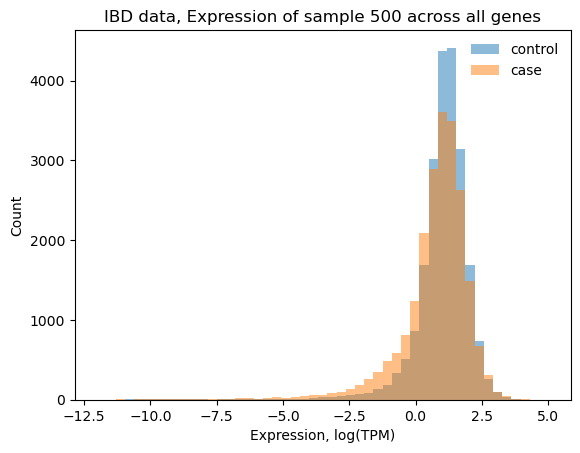

In [12]:
m=500
fig,ax = plt.subplots(1,1)
for state in ['control','case']:
    ax.hist(ibd_df.xs(state).iloc[m,:],bins=np.linspace(-12,5),alpha=.5,label=state)
ax.set_title('IBD data, Expression of sample {} across all genes'.format(m))
ax.set_ylabel('Count')
ax.set_xlabel('Expression, log(TPM)')
ax.legend(frameon=False)


### Make histogram of a single gene for both case and control

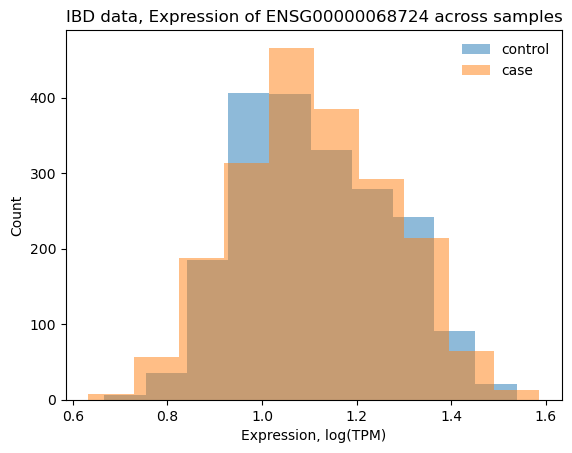

In [6]:
n=1000
fig,ax = plt.subplots(1,1)
for state in ['control','case']:
    ax.hist(ibd_df.xs(state).iloc[:,n],alpha=.5,label=state)
ax.set_title('IBD data, Expression of {} across samples'.format(ibd_df.columns[n]) )
ax.set_ylabel('Count')
ax.set_xlabel('Expression, log(TPM)')
ax.legend(frameon=False)

### Make histogram of a single profile for both case and control

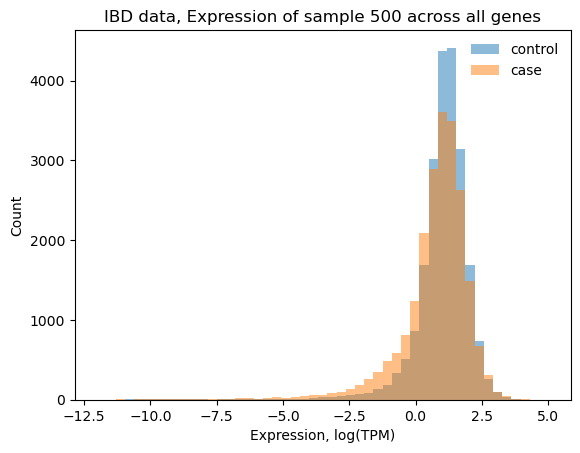

In [7]:
m=500
fig,ax = plt.subplots(1,1)
for state in ['control','case']:
    ax.hist(ibd_df.xs(state).iloc[m,:],bins=np.linspace(-12,5),alpha=.5,label=state)
ax.set_title('IBD data, Expression of sample {} across all genes'.format(m))
ax.set_ylabel('Count')
ax.set_xlabel('Expression, log(TPM)')
ax.legend(frameon=False)


Text(0.5, 0, 'Avg. expression, log(TPM)')

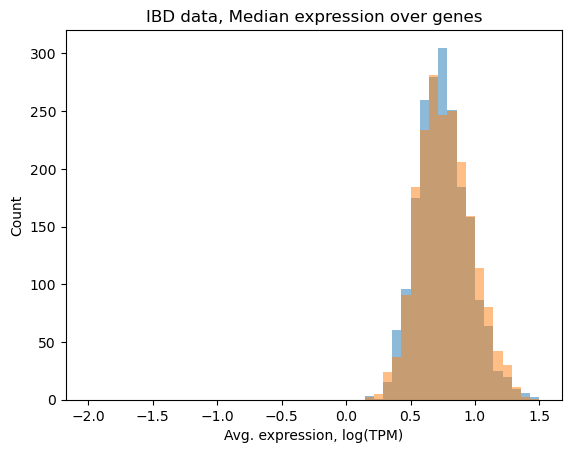

In [8]:
fig,ax = plt.subplots(1,1)
for state in ['control','case']:
    ax.hist(ibd_df.xs(state).T.median(),bins=np.linspace(-2,1.5),alpha=.5,label=state)
ax.set_title('IBD data, Median expression over genes')
ax.set_ylabel('Count')
ax.set_xlabel('Avg. expression, log(TPM)')


### Import TWAS associations

In [4]:
#these are gene level associations that have a SNP level contribution
#(expression changes in a trait from purely genetic causes)

#these first two tables are all the genes found for every disease in both TWAS Atlas and
#webTWAS. This defines their coverage
all_twas_atlas = pd.read_csv(f'{indir}/twas_atlas_downloadgenes.txt.gz',delimiter='\t',compression='gzip')[['Gene Symbol','Ensembl ID']]

#pick off trailing numbers on ensg identifier
all_twas_atlas['Ensembl ID'] = all_twas_atlas['Ensembl ID'].apply(lambda x: x.split('.')[0])


all_twas_web = pd.read_excel(f'{indir}/all_webtwas.xlsx')[['geneSymbol','ensemblId']]
all_twas_web = all_twas_web.rename(columns={'geneSymbol':'Gene Symbol', 'ensemblId': 'Ensembl ID'})

#get disease specific data
ibd_atlas = pd.read_csv(f'{indir}/TWASAtlas_IBD_all.csv')[['Tissues','Gene Symbol','Ensembl ID']]
ibd_atlas['Ensembl ID'] = ibd_atlas['Ensembl ID'].apply(lambda x: x.split('.')[0])
ibd_atlas = ibd_atlas.drop_duplicates('Ensembl ID').reset_index(drop=True)
ibd_web = pd.read_excel(f'{indir}/webTWAS_IBD.xlsx')[['Gene Symbol','Ensembl ID','Tissue']]
ibd_web = ibd_web.rename(columns={'Tissue':'Tissues'})
ibd_web = ibd_web.drop_duplicates('Ensembl ID').reset_index(drop=True)

/home/thomas/miniforge3/envs/reprog_design/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/home/thomas/miniforge3/envs/reprog_design/lib/python3.9/site-packages/openpyxl/styles/stylesheet.py:226: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [8]:
DE_gns = pd.read_excel(f'{indir}/gutjnl-2023-July-72-7-1271-inline-supplementary-material-1.xlsx',
                       sheet_name='Table 6',header=2,index_col=0).fillna(0)
DE_gns_counts = DE_gns.sum(axis=1)

In [9]:
all_twas_gns = pd.concat([all_twas_web,all_twas_atlas])
all_twas_gns = all_twas_gns[~all_twas_gns['Gene Symbol'].duplicated()]
common_gns = set(all_twas_gns['Gene Symbol'].values) & set(DE_gns_counts.index)
original_DE_ensgs = set(all_twas_gns.set_index('Gene Symbol').loc[list(common_gns),'Ensembl ID'].values)

In [10]:
ibd_twas_ensgs = list(set(ibd_web['Ensembl ID'].values)|set(ibd_atlas['Ensembl ID'].values))
ovr = len(set(ibd_twas_ensgs)&set(all_twas_gns.set_index('Gene Symbol').loc[list(common_gns),'Ensembl ID']))
print('Fraction overlap (DE literature v. TWAS):',ovr/len(common_gns))

Fraction overlap (DE literature v. TWAS): 0.08018867924528301


## DE vs. Perts

### Load the $u_{opt}$ point-to-point results and label perturbations

In [27]:
## load the average uopt data 
fwd_df = pd.read_csv(f'{indir}/uopt_IBD_forward_df.csv.gz',compression='gzip',index_col=[0,1])

### Aggregate the results by the perturbations

In [28]:
## put the labels used to coarse-grain the responses onto the columns
fwd_pert_sum_d = {}
for pert_nm,rid_df in rid2pert_ser.to_frame().groupby(0):
    fwd_pert_sum_d[pert_nm] = (fwd_df.loc[:,rid_df.index].T).sum(axis=0).sum()
fwd_pert_sum_ser = pd.Series(fwd_pert_sum_d).sort_values(ascending=False)
 

In [29]:
fwd_ensgs = set.union(*[set(pert2ENSG_d[k]) for k in fwd_pert_sum_ser.index])
all_pert_ensgs = set.union(*[set(pert2ENSG_d[k]) for k in fwd_pert_sum_ser.index])
len(set(fwd_ensgs)),len(set(ibd_twas_ensgs)&set(all_pert_ensgs)),len(set(ibd_twas_ensgs)&set(all_pert_ensgs)&set(fwd_ensgs))


(719, 44, 44)

## Make Figure panels

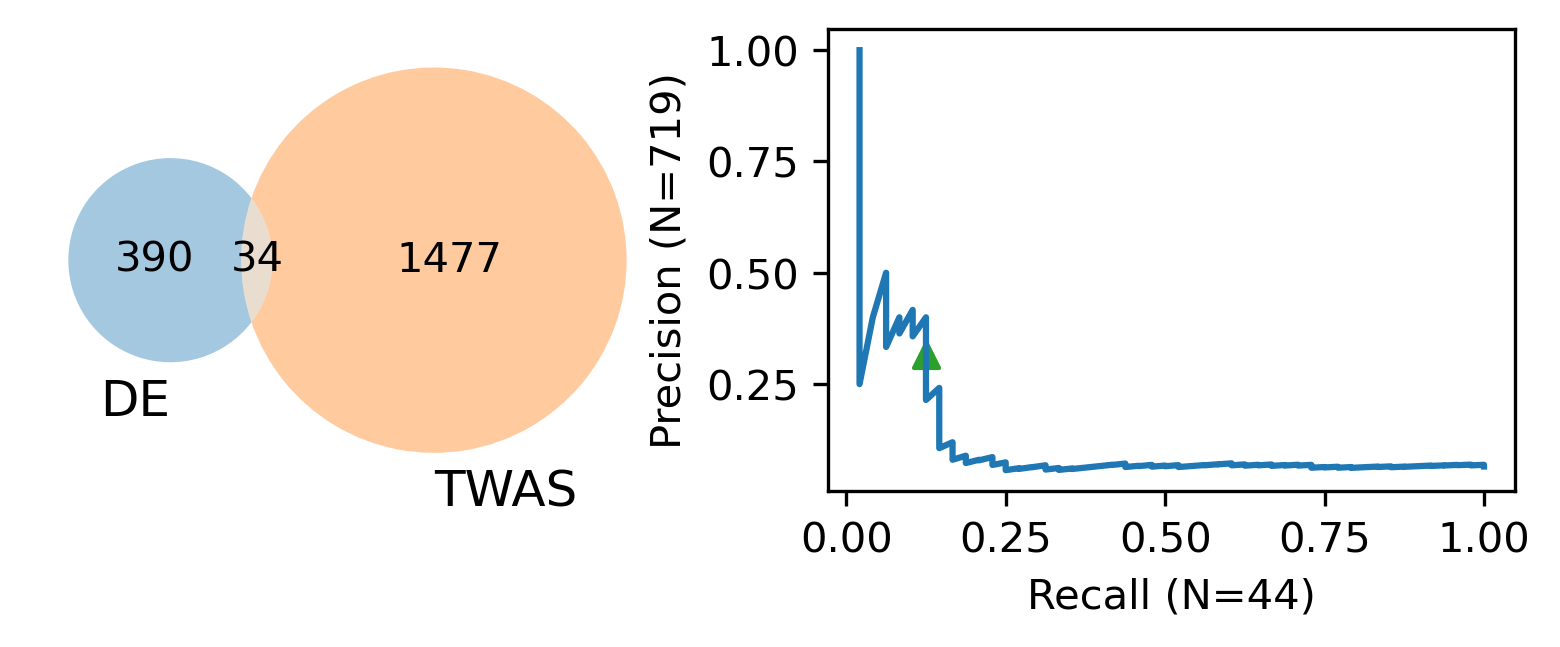

In [32]:
fig,ax_arr = plt.subplots(1,2,dpi=300,figsize=(6.5,2))
y_true = np.asarray([len(set(pert2ENSG_d[pert_nm]) & set(ibd_twas_ensgs))>0 for pert_nm in fwd_pert_sum_ser.index ])
prec = np.cumsum(y_true)/(1+np.arange(y_true.shape[0]))
rec = np.cumsum(y_true)/np.sum(y_true)
venn2([original_DE_ensgs, set(ibd_twas_ensgs)], ('DE', 'TWAS'),set_colors=['C0','C1'], ax=ax_arr[0])
#venn2([], ax=ax_arr[0])
ax_arr[1].plot(rec,prec)
ax_arr[1].set_ylabel('Precision (N=719)')
ax_arr[1].set_xlabel('Recall (N=44)')
ax_arr[1].scatter([rec[18]],[prec[18]], marker='^',color='C2')
fig.savefig(f'{outdir}/ibd_comparison.svg')

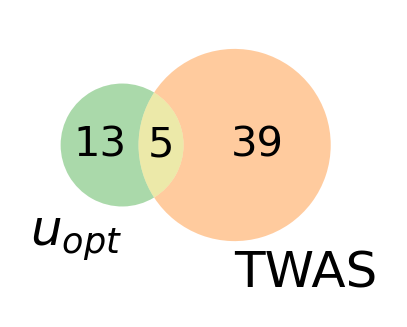

In [33]:
fig,ax = plt.subplots(1,1,dpi=300,figsize=(1.75,1))
S1 = set.union(*[set(pert2ENSG_d[pert_nm]) for pert_nm in fwd_pert_sum_ser[fwd_pert_sum_ser>1250].index])
S2 = all_pert_ensgs & set(ibd_twas_ensgs)
venn2([S1,S2],(r'$u_{opt}$','TWAS'),set_colors=['C2','C1'],ax=ax)
fig.savefig(f'{outdir}/ibd_twas_venn_diagram.svg')